[WARNING] get_db_host 로드 실패: name '__file__' is not defined
[INFO] ======================================================================
[INFO] 관광통계 시각화
[INFO] ======================================================================
[INFO] tourism_indus_stats 테이블에서 데이터 불러오기...
[WARNING] get_db_host 사용 불가. 하드코딩된 IP 사용
[INFO] ✓ 데이터 로드 완료: 288개 레코드
[INFO] ✓ 기간: 202001 ~ 202512
[INFO] 
[데이터 요약]
[INFO] 총 레코드: 288개
[INFO] 기간: 202001 ~ 202512
[INFO] 구분: 입국, 출국
[INFO] 국가: 미국, 일본, 중국, 한국
[INFO] YoY 데이터: 240개
[INFO] 
[1/5] 한국 출국자수 시각화...


C:\Users\82108\AppData\Local\Temp\ipykernel_25896\3643134024.py:119: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


[INFO] ✓ 그래프 저장: tourism_outbound.png


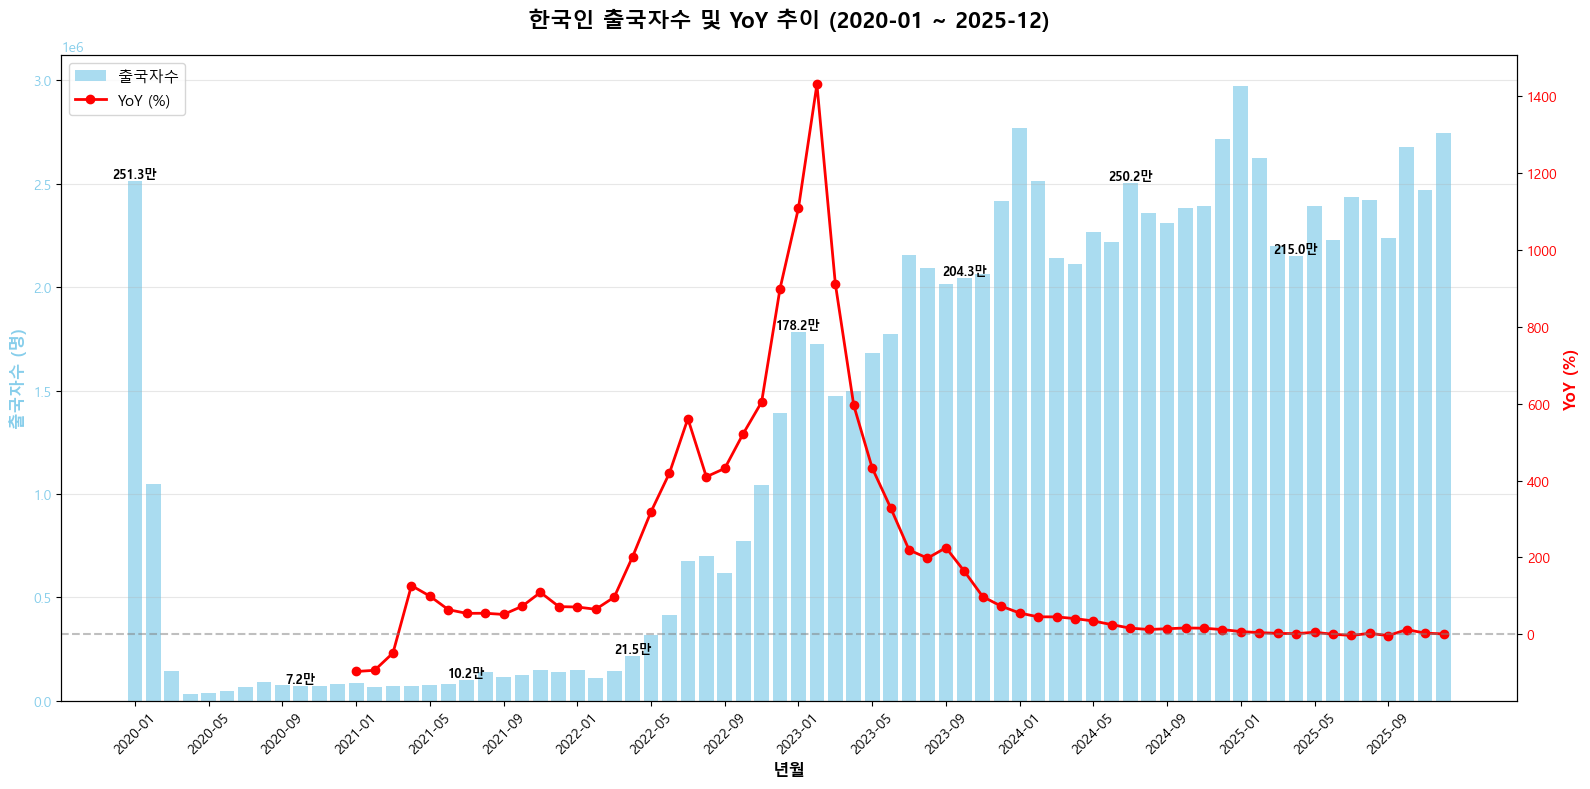

[INFO] 
[2/5] 중국 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_china.png


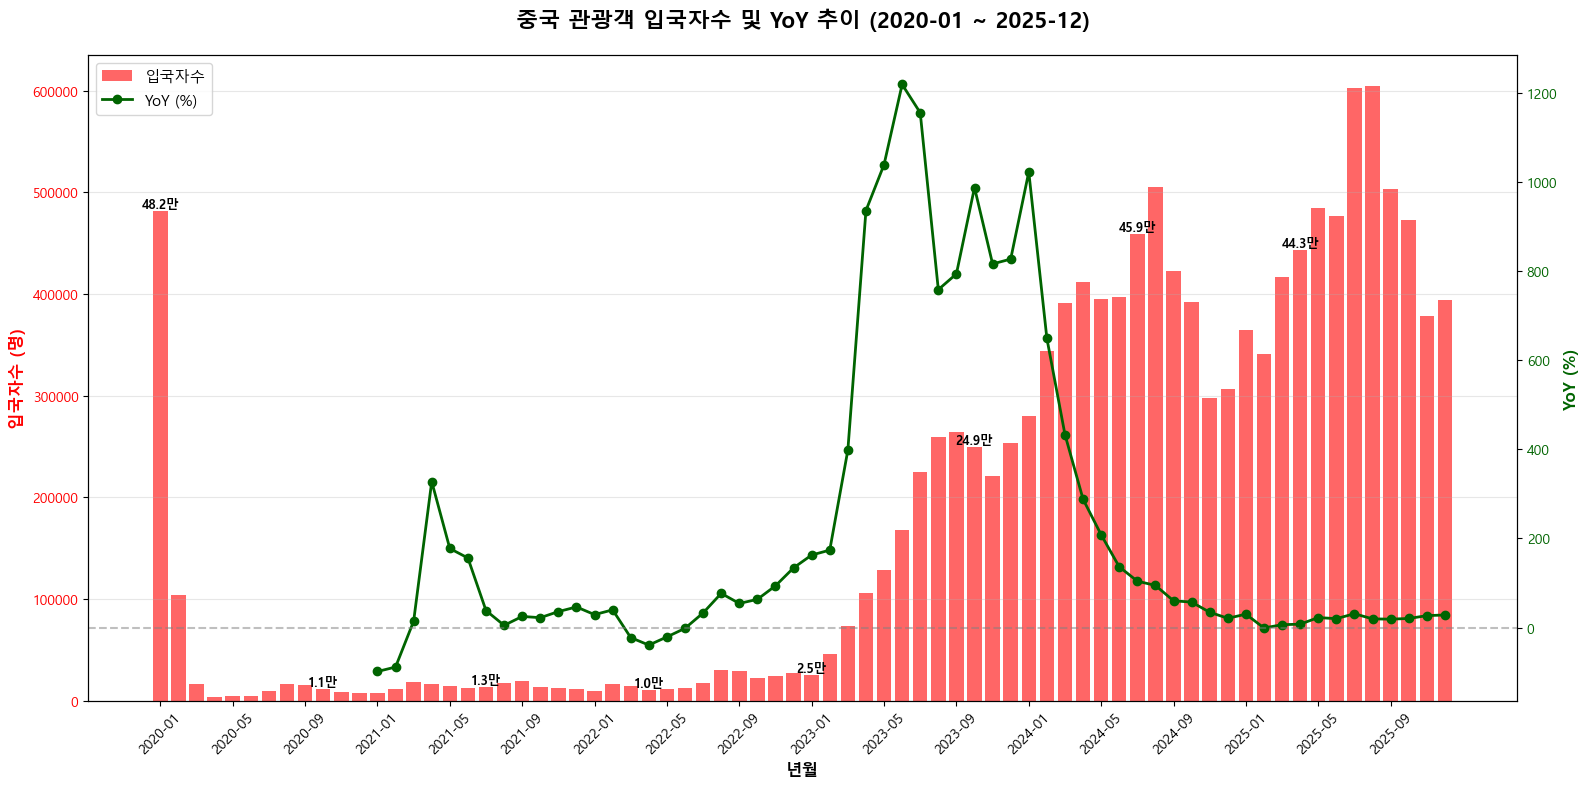

[INFO] 
[3/5] 일본 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_japan.png


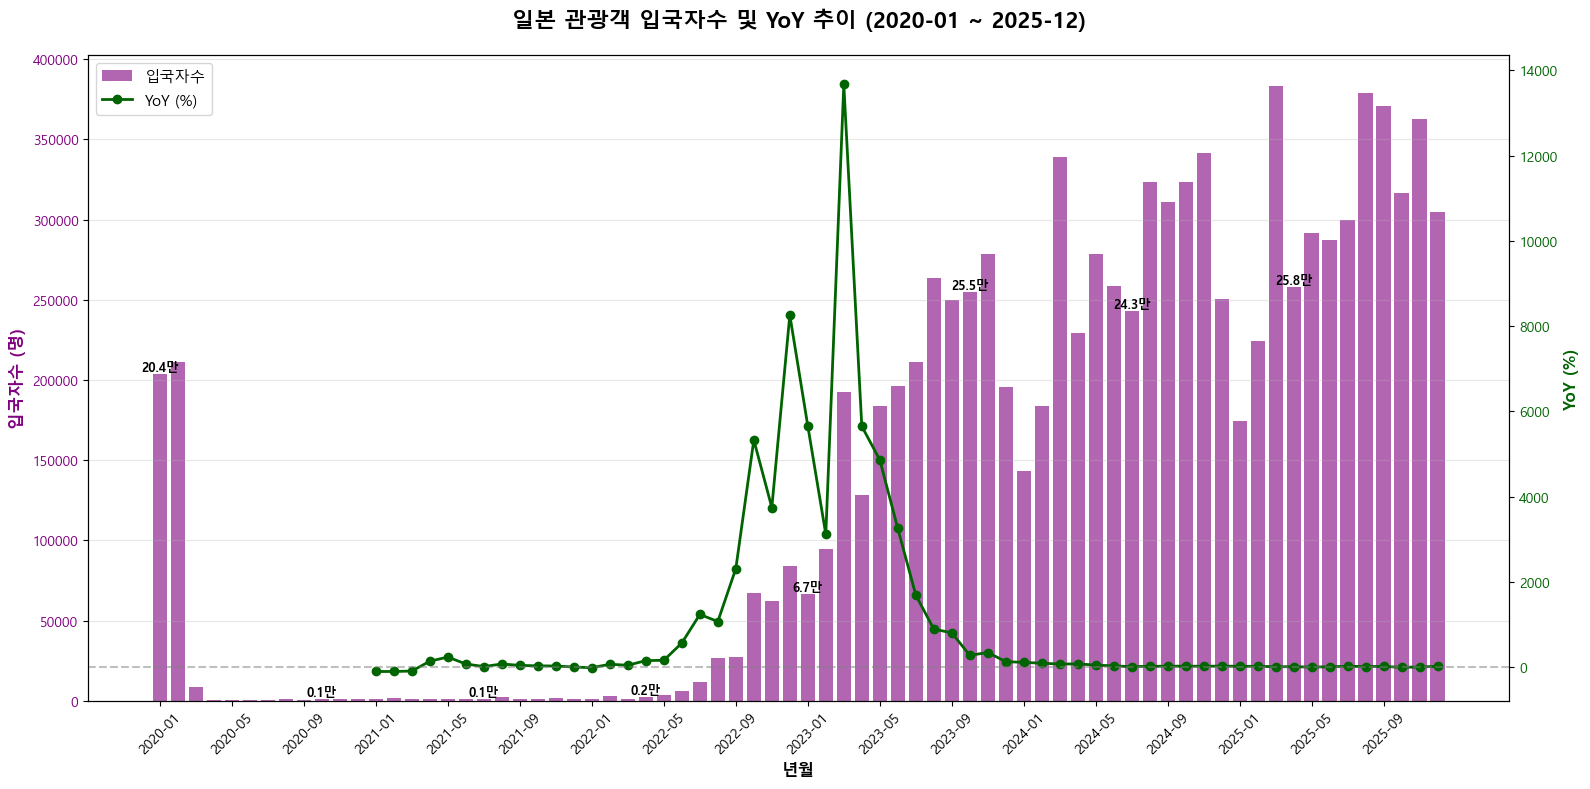

[INFO] 
[4/5] 미국 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_usa.png


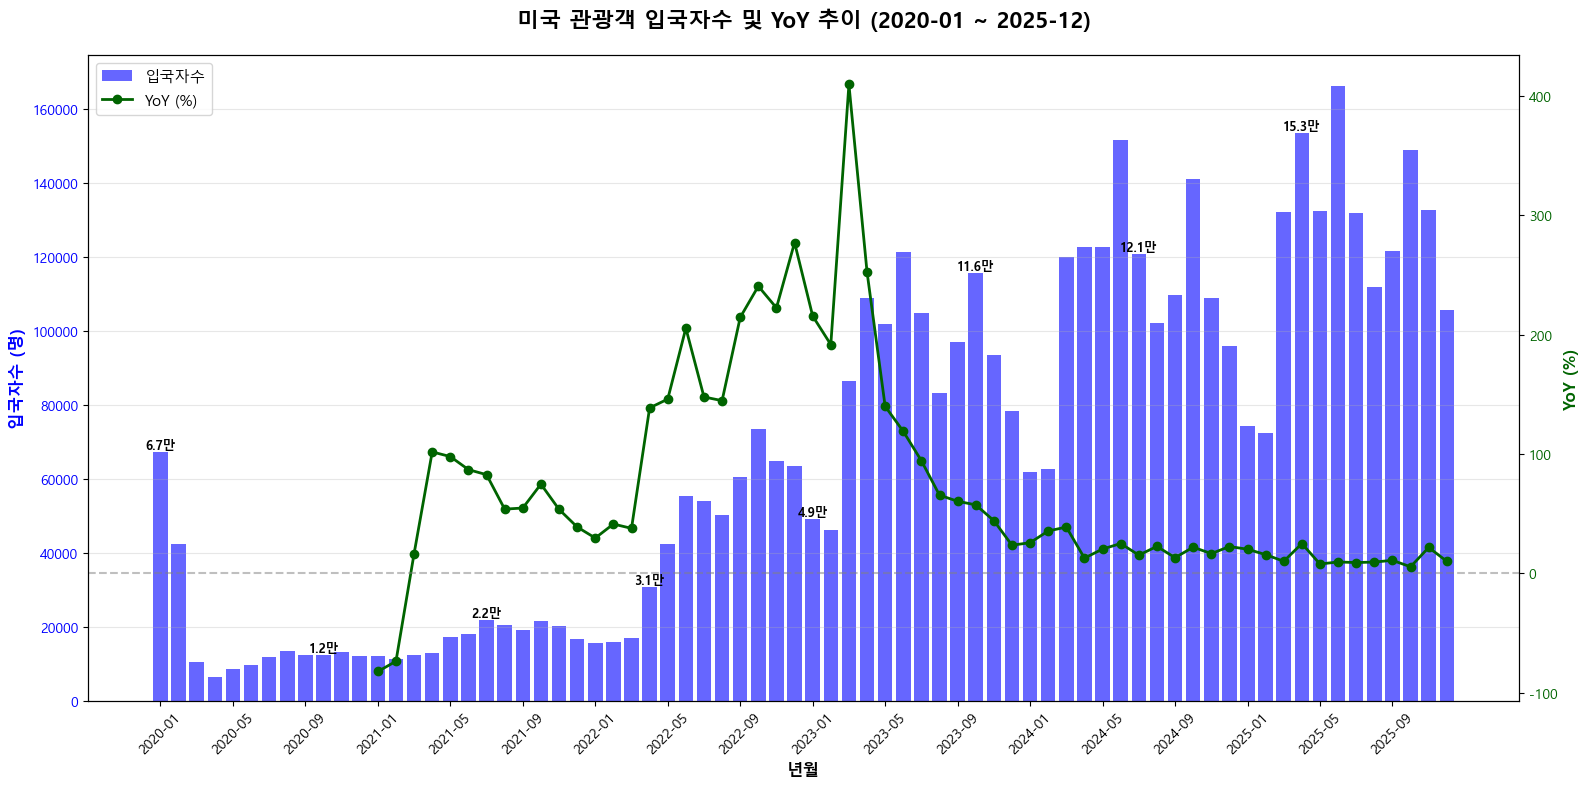

[INFO] 
[5/5] 국가별 입국자수 비교 시각화...
[INFO] ✓ 그래프 저장: tourism_comparison.png


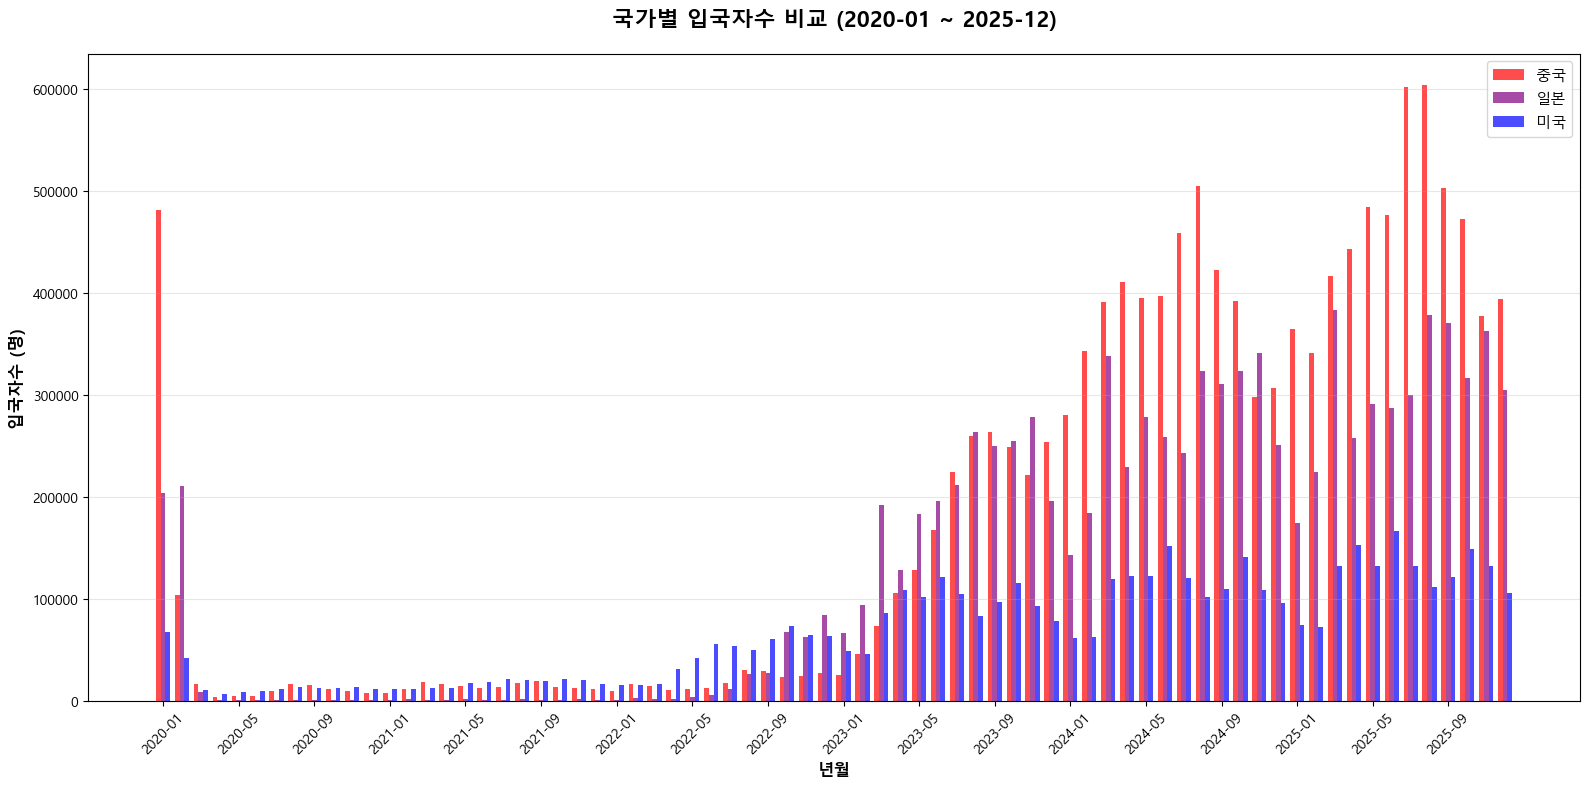

[INFO] 
[INFO] ✓ 시각화 완료!
[INFO] ======================================================================
[INFO] 
생성된 파일:
[INFO]   - tourism_outbound.png
[INFO]   - tourism_china.png
[INFO]   - tourism_japan.png
[INFO]   - tourism_usa.png
[INFO]   - tourism_comparison.png
[INFO] ======================================================================
[INFO] 관광통계 시각화
[INFO] ======================================================================
[INFO] tourism_indus_stats 테이블에서 데이터 불러오기...
[WARNING] get_db_host 사용 불가. 하드코딩된 IP 사용
[INFO] ✓ 데이터 로드 완료: 288개 레코드
[INFO] ✓ 기간: 202001 ~ 202512
[INFO] 기간 필터링: 202401 ~ 끝
[INFO] 
[데이터 요약]
[INFO] 총 레코드: 96개
[INFO] 기간: 202401 ~ 202512
[INFO] 구분: 입국, 출국
[INFO] 국가: 미국, 일본, 중국, 한국
[INFO] YoY 데이터: 96개
[INFO] 
[1/5] 한국 출국자수 시각화...


C:\Users\82108\AppData\Local\Temp\ipykernel_25896\3643134024.py:119: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


[INFO] ✓ 그래프 저장: tourism_outbound.png


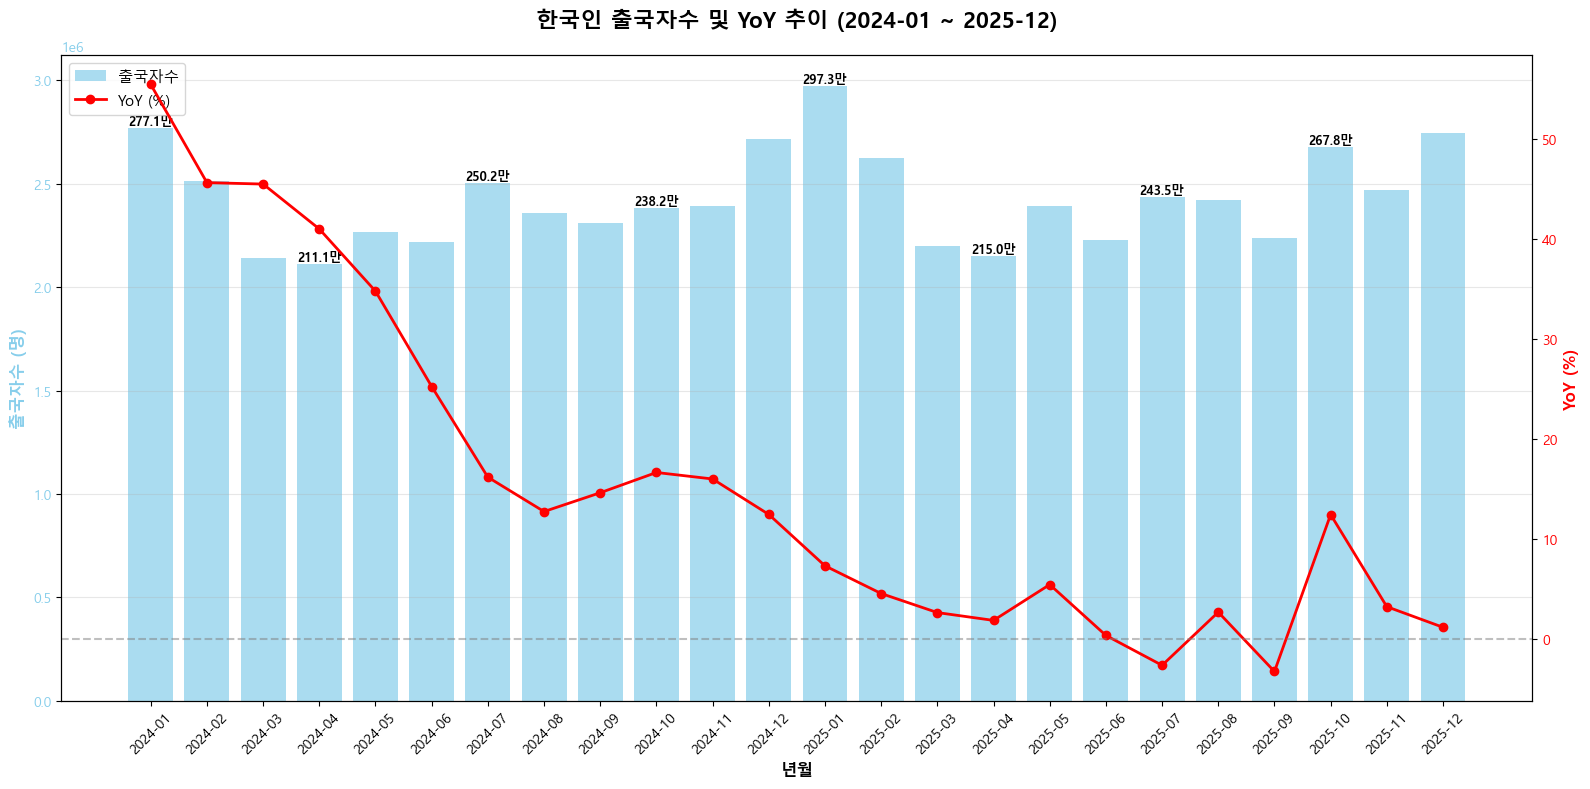

[INFO] 
[2/5] 중국 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_china.png


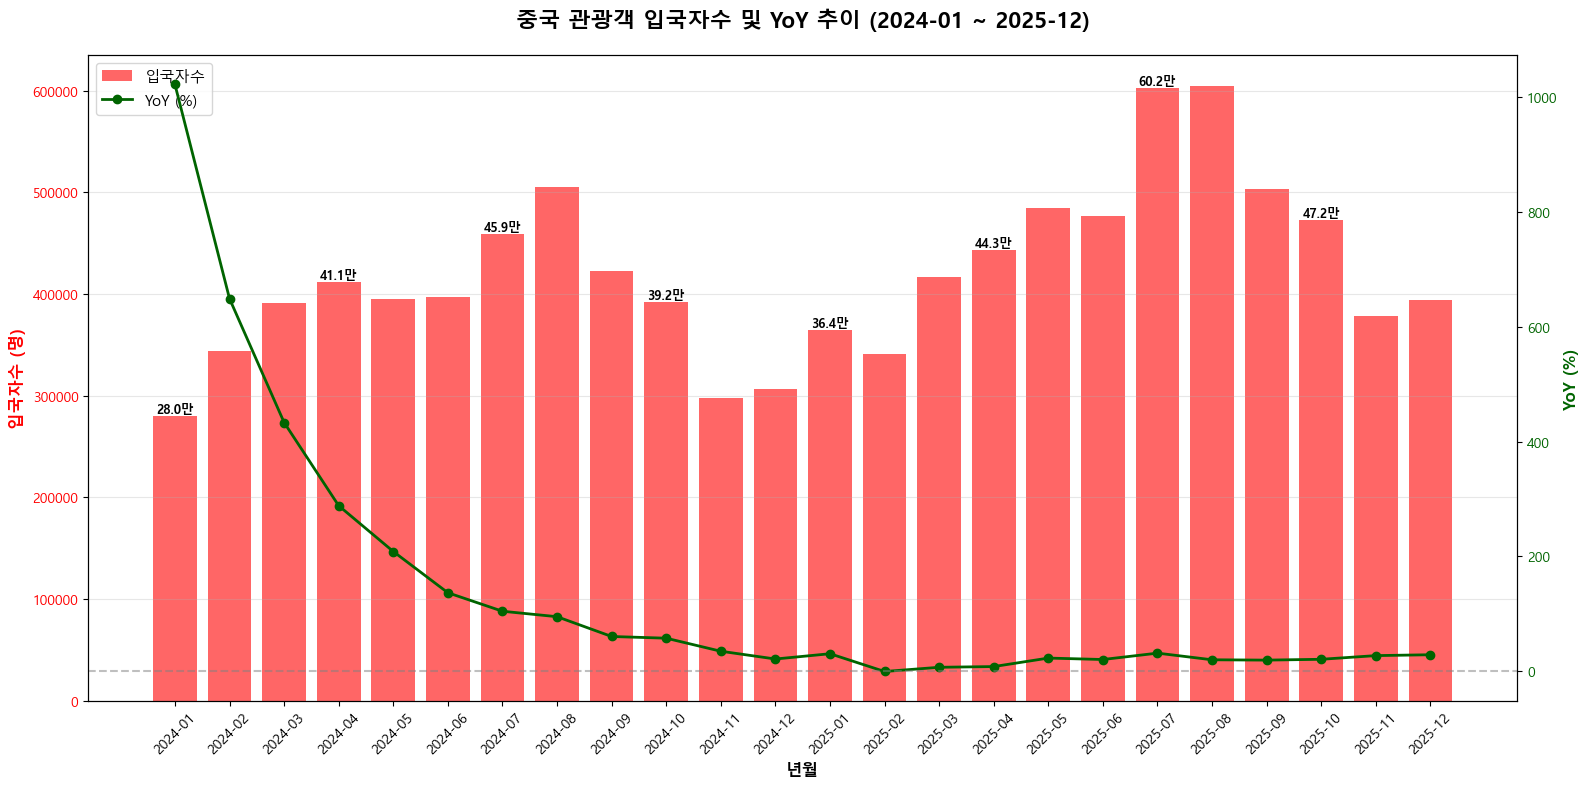

[INFO] 
[3/5] 일본 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_japan.png


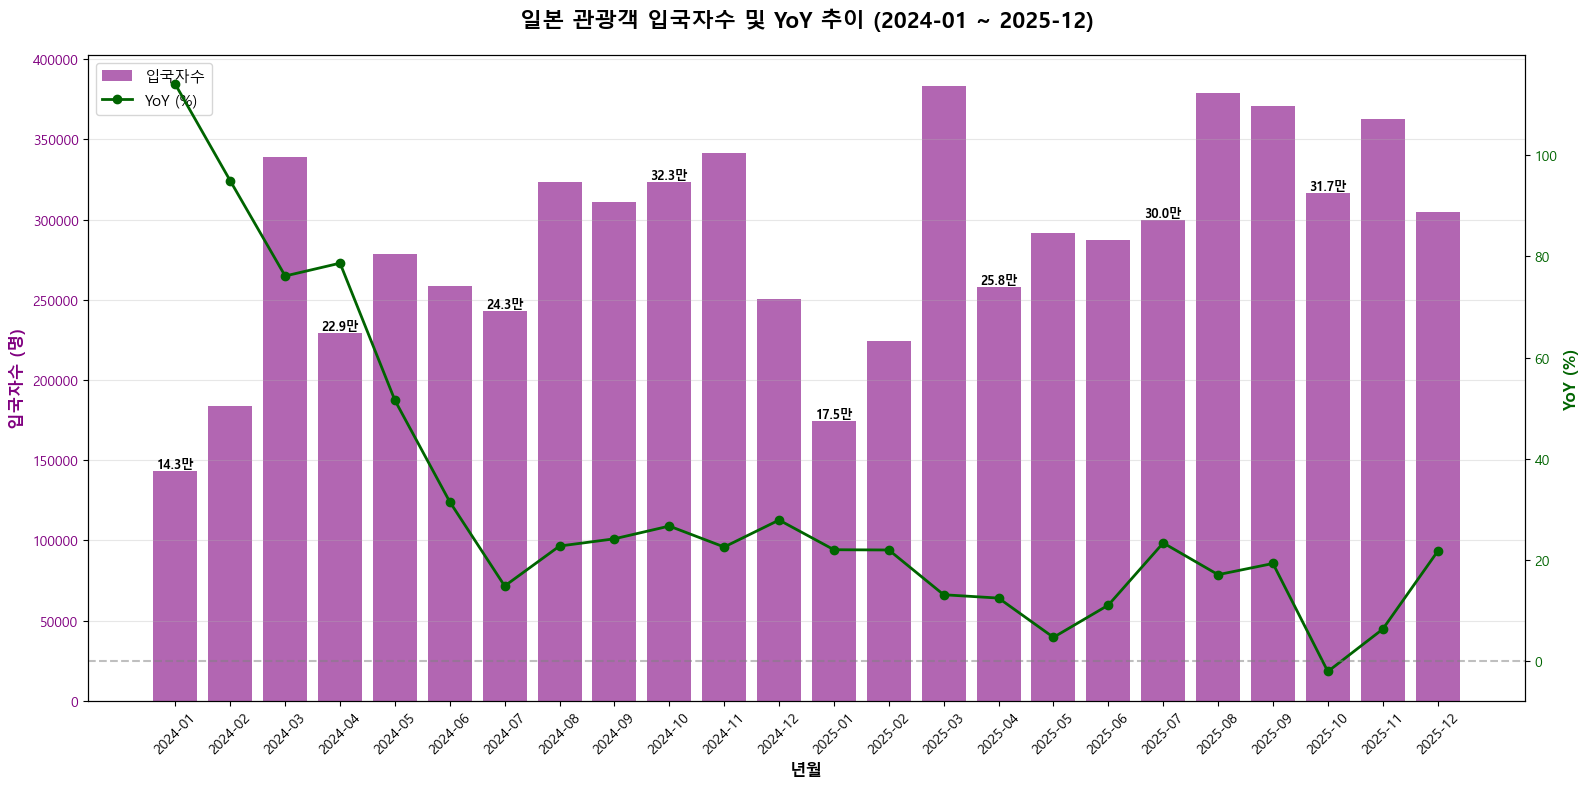

[INFO] 
[4/5] 미국 관광객 입국자수 시각화...
[INFO] ✓ 그래프 저장: tourism_usa.png


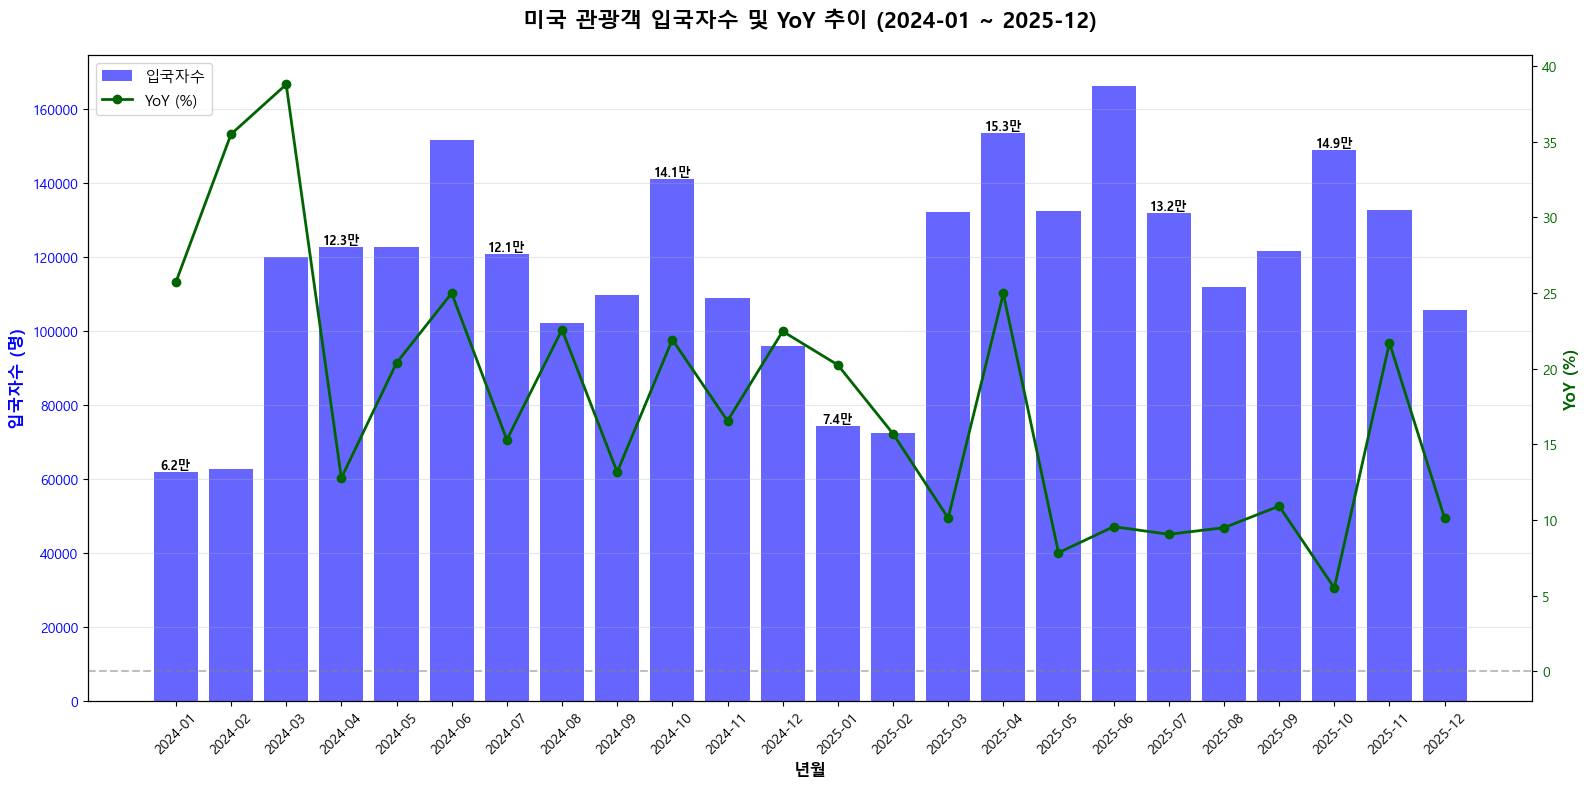

[INFO] 
[5/5] 국가별 입국자수 비교 시각화...
[INFO] ✓ 그래프 저장: tourism_comparison.png


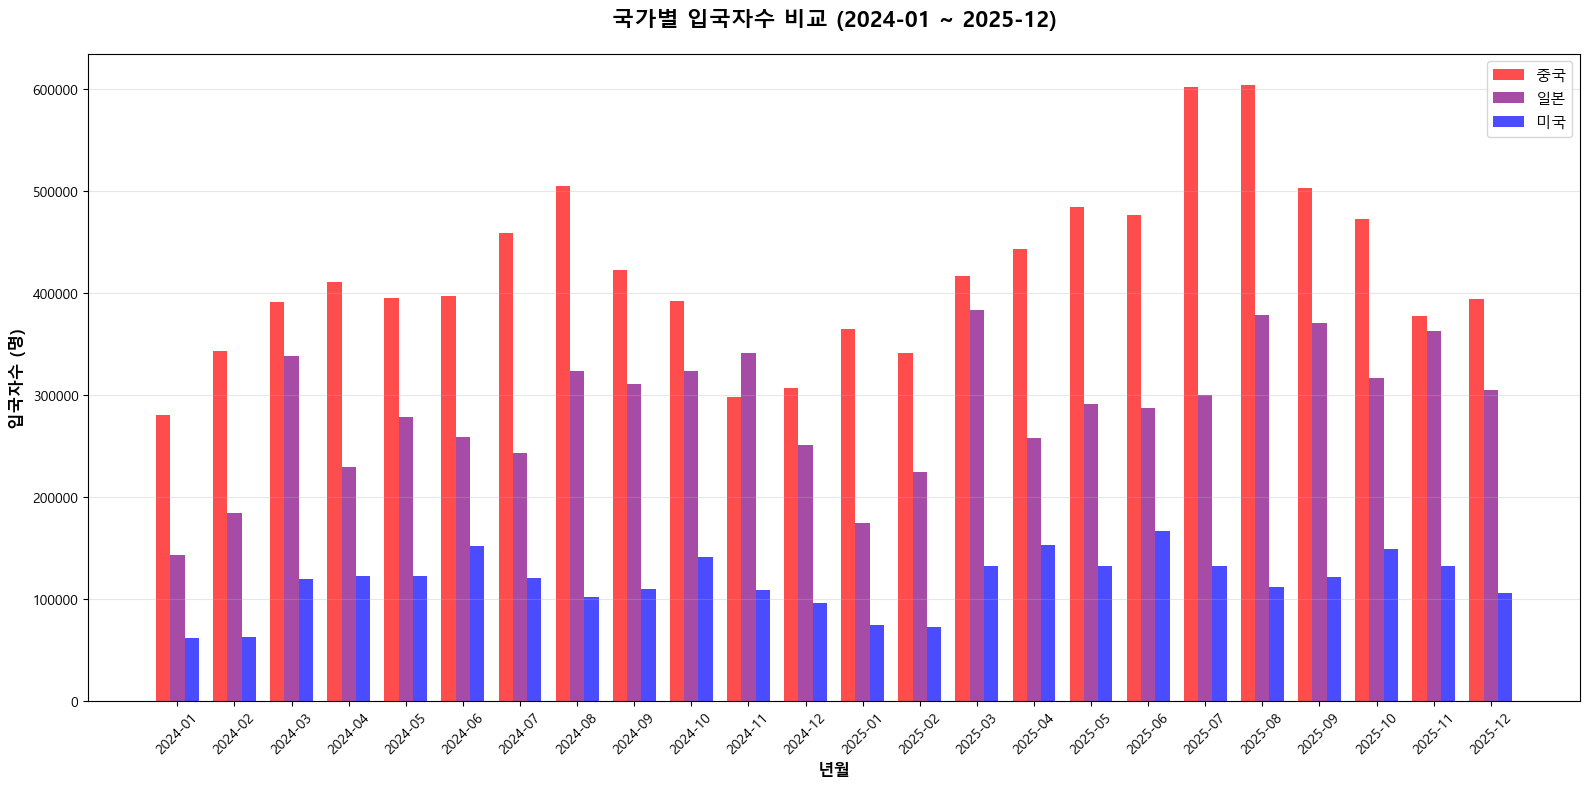

[INFO] 
[INFO] ✓ 시각화 완료!
[INFO] ======================================================================
[INFO] 
생성된 파일:
[INFO]   - tourism_outbound.png
[INFO]   - tourism_china.png
[INFO]   - tourism_japan.png
[INFO]   - tourism_usa.png
[INFO]   - tourism_comparison.png


In [8]:
"""
관광통계 시각화 (tourism_visualization.py)
- stock_invest_function에서 get_db_host 직접 import
- DB에서 관광통계 데이터 로드
- 출국자수 및 국가별 입국자수 시계열 막대차트 생성
- YoY 증감률 함께 표시
- 기간 조정 가능
"""

import pandas as pd
import matplotlib.pyplot as plt
import pymysql
from typing import Dict, Optional
import sys
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def log(tag: str, msg: str):
    """로그 출력"""
    print(f"[{tag}] {msg}", file=sys.stdout, flush=True)


# stock_invest_function.py에서 get_db_host 직접 import
def import_get_db_host():
    """get_db_host 함수를 동적으로 import"""
    try:
        # 프로젝트 루트 찾기
        current_file = Path(__file__).resolve()

        # investment_strategy/DATA 경로 찾기
        base_dir = current_file
        for _ in range(5):
            base_dir = base_dir.parent
            data_dir = base_dir / "DATA"
            if data_dir.exists():
                break

        if not data_dir.exists():
            raise FileNotFoundError(f"DATA 폴더를 찾을 수 없습니다")

        # DATA 폴더의 상위를 sys.path에 추가
        if str(base_dir) not in sys.path:
            sys.path.insert(0, str(base_dir))

        # stock_invest_function에서 get_db_host import
        from DATA.stock_invest_function import get_db_host

        log("INFO", f"✓ get_db_host 함수 로드 성공")
        return get_db_host

    except Exception as e:
        log("WARNING", f"get_db_host 로드 실패: {e}")
        return None


# get_db_host 함수 로드
get_db_host_func = import_get_db_host()


def get_db_info() -> Dict[str, str]:
    """DB 연결 정보 반환"""
    if get_db_host_func:
        try:
            host = get_db_host_func()
            db_info = {
                "host": host,
                "port": 3307,
                "user": "stox7412",
                "password": "Apt106503!~",
                "database": "investar",
            }
            log("INFO", f"✓ DB 정보: {host}:3307")
            return db_info
        except Exception as e:
            log("WARNING", f"get_db_host() 실행 실패: {e}")

    # Fallback: 하드코딩된 IP 사용
    log("WARNING", "get_db_host 사용 불가. 하드코딩된 IP 사용")
    return {
        "host": "192.168.0.230",
        "port": 3307,
        "user": "stox7412",
        "password": "Apt106503!~",
        "database": "investar",
    }


def load_tourism_data(table_name: str = 'tourism_indus_stats') -> pd.DataFrame:
    """
    DB에서 관광통계 데이터 로드

    Args:
        table_name: 테이블 이름

    Returns:
        DataFrame
    """
    log("INFO", f"{table_name} 테이블에서 데이터 불러오기...")

    try:
        # DB 정보 가져오기
        db_info = get_db_info()

        # PyMySQL 직접 연결
        connection = pymysql.connect(
            host=db_info['host'],
            port=db_info['port'],
            user=db_info['user'],
            password=db_info['password'],
            database=db_info['database'],
            charset='utf8mb4'
        )

        query = f"SELECT * FROM {table_name} ORDER BY 년월, 구분, 국가"
        df = pd.read_sql(query, con=connection)

        connection.close()

        log("INFO", f"✓ 데이터 로드 완료: {len(df)}개 레코드")
        log("INFO", f"✓ 기간: {df['년월'].min()} ~ {df['년월'].max()}")

        return df

    except Exception as e:
        log("ERROR", f"데이터 로드 실패: {e}")
        raise


def filter_by_period(df: pd.DataFrame, start_ym: Optional[str] = None,
                     end_ym: Optional[str] = None) -> pd.DataFrame:
    """
    기간별 데이터 필터링

    Args:
        df: DataFrame
        start_ym: 시작 년월 (YYYYMM), None이면 전체
        end_ym: 종료 년월 (YYYYMM), None이면 전체

    Returns:
        필터링된 DataFrame
    """
    filtered_df = df.copy()

    if start_ym:
        filtered_df = filtered_df[filtered_df['년월'] >= start_ym]

    if end_ym:
        filtered_df = filtered_df[filtered_df['년월'] <= end_ym]

    return filtered_df


def plot_outbound_stats(df: pd.DataFrame, save_path: str = None):
    """한국 출국자수 및 YoY 시각화"""
    outbound_df = df[(df['구분'] == '출국') & (df['국가'] == '한국')].copy()
    outbound_df['년월_dt'] = pd.to_datetime(outbound_df['년월'], format='%Y%m')
    outbound_df = outbound_df.sort_values('년월_dt')

    if len(outbound_df) == 0:
        log("WARNING", "출국 데이터가 없습니다.")
        return

    fig, ax1 = plt.subplots(figsize=(16, 8))

    x = range(len(outbound_df))
    bars = ax1.bar(x, outbound_df['관광객수'], color='skyblue', alpha=0.7, label='출국자수')
    ax1.set_xlabel('년월', fontsize=12, fontweight='bold')
    ax1.set_ylabel('출국자수 (명)', fontsize=12, fontweight='bold', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')

    # x축 레이블 간격 조정 (데이터 개수에 따라)
    step = max(1, len(outbound_df) // 15)  # 최대 15개 레이블
    ax1.set_xticks(x[::step])
    ax1.set_xticklabels(outbound_df['년월_dt'].dt.strftime('%Y-%m').iloc[::step], rotation=45)
    ax1.grid(axis='y', alpha=0.3)

    # 값 표시 간격 조정
    value_step = max(1, len(outbound_df) // 8)  # 최대 8개 값 표시
    for i in x[::value_step]:
        value = outbound_df['관광객수'].iloc[i]
        ax1.text(i, value, f'{value/10000:.1f}만',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2 = ax1.twinx()
    yoy_data = outbound_df['yoy_rate'].dropna()
    yoy_x = [i for i, val in enumerate(outbound_df['yoy_rate']) if pd.notna(val)]

    if len(yoy_data) > 0:
        line = ax2.plot(yoy_x, yoy_data, color='red', marker='o', linewidth=2,
                        markersize=6, label='YoY (%)', linestyle='-')
        ax2.set_ylabel('YoY (%)', fontsize=12, fontweight='bold', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    else:
        ax1.legend(loc='upper left', fontsize=11)

    period_text = f"{outbound_df['년월_dt'].min().strftime('%Y-%m')} ~ {outbound_df['년월_dt'].max().strftime('%Y-%m')}"
    plt.title(f'한국인 출국자수 및 YoY 추이 ({period_text})', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        log("INFO", f"✓ 그래프 저장: {save_path}")

    plt.show()


def plot_inbound_stats(df: pd.DataFrame, country: str, save_path: str = None):
    """국가별 입국자수 및 YoY 시각화"""
    inbound_df = df[(df['구분'] == '입국') & (df['국가'] == country)].copy()
    inbound_df['년월_dt'] = pd.to_datetime(inbound_df['년월'], format='%Y%m')
    inbound_df = inbound_df.sort_values('년월_dt')

    if len(inbound_df) == 0:
        log("WARNING", f"{country} 입국 데이터가 없습니다.")
        return

    color_map = {'중국': 'red', '일본': 'purple', '미국': 'blue'}
    bar_color = color_map.get(country, 'gray')

    fig, ax1 = plt.subplots(figsize=(16, 8))

    x = range(len(inbound_df))
    bars = ax1.bar(x, inbound_df['관광객수'], color=bar_color, alpha=0.6, label='입국자수')
    ax1.set_xlabel('년월', fontsize=12, fontweight='bold')
    ax1.set_ylabel('입국자수 (명)', fontsize=12, fontweight='bold', color=bar_color)
    ax1.tick_params(axis='y', labelcolor=bar_color)

    # x축 레이블 간격 조정
    step = max(1, len(inbound_df) // 15)
    ax1.set_xticks(x[::step])
    ax1.set_xticklabels(inbound_df['년월_dt'].dt.strftime('%Y-%m').iloc[::step], rotation=45)
    ax1.grid(axis='y', alpha=0.3)

    # 값 표시 간격 조정
    value_step = max(1, len(inbound_df) // 8)
    for i in x[::value_step]:
        value = inbound_df['관광객수'].iloc[i]
        ax1.text(i, value, f'{value/10000:.1f}만',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2 = ax1.twinx()
    yoy_data = inbound_df['yoy_rate'].dropna()
    yoy_x = [i for i, val in enumerate(inbound_df['yoy_rate']) if pd.notna(val)]

    if len(yoy_data) > 0:
        line = ax2.plot(yoy_x, yoy_data, color='darkgreen', marker='o', linewidth=2,
                        markersize=6, label='YoY (%)', linestyle='-')
        ax2.set_ylabel('YoY (%)', fontsize=12, fontweight='bold', color='darkgreen')
        ax2.tick_params(axis='y', labelcolor='darkgreen')
        ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    else:
        ax1.legend(loc='upper left', fontsize=11)

    period_text = f"{inbound_df['년월_dt'].min().strftime('%Y-%m')} ~ {inbound_df['년월_dt'].max().strftime('%Y-%m')}"
    plt.title(f'{country} 관광객 입국자수 및 YoY 추이 ({period_text})', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        log("INFO", f"✓ 그래프 저장: {save_path}")

    plt.show()


def plot_all_inbound_comparison(df: pd.DataFrame, save_path: str = None):
    """전체 국가별 입국자수 비교 시각화"""
    inbound_df = df[df['구분'] == '입국'].copy()

    if len(inbound_df) == 0:
        log("WARNING", "입국 데이터가 없습니다.")
        return

    inbound_df['년월_dt'] = pd.to_datetime(inbound_df['년월'], format='%Y%m')

    pivot_df = inbound_df.pivot_table(
        index='년월_dt',
        columns='국가',
        values='관광객수'
    ).reset_index()
    pivot_df = pivot_df.sort_values('년월_dt')

    fig, ax = plt.subplots(figsize=(16, 8))

    x = range(len(pivot_df))
    width = 0.25

    colors = {'중국': 'red', '일본': 'purple', '미국': 'blue'}

    for i, country in enumerate(['중국', '일본', '미국']):
        if country in pivot_df.columns:
            ax.bar([xi + width * i for xi in x], pivot_df[country],
                   width=width, label=country, color=colors[country], alpha=0.7)

    ax.set_xlabel('년월', fontsize=12, fontweight='bold')
    ax.set_ylabel('입국자수 (명)', fontsize=12, fontweight='bold')

    # x축 레이블 간격 조정
    step = max(1, len(pivot_df) // 15)
    ax.set_xticks([xi + width for xi in x[::step]])
    ax.set_xticklabels(pivot_df['년월_dt'].dt.strftime('%Y-%m').iloc[::step], rotation=45)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    period_text = f"{pivot_df['년월_dt'].min().strftime('%Y-%m')} ~ {pivot_df['년월_dt'].max().strftime('%Y-%m')}"
    plt.title(f'국가별 입국자수 비교 ({period_text})', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        log("INFO", f"✓ 그래프 저장: {save_path}")

    plt.show()


def main(start_ym: Optional[str] = None, end_ym: Optional[str] = None):
    """
    메인 실행 함수

    Args:
        start_ym: 시작 년월 (YYYYMM 형식, 예: '202201'), None이면 전체
        end_ym: 종료 년월 (YYYYMM 형식, 예: '202412'), None이면 전체
    """

    log("INFO", "=" * 70)
    log("INFO", "관광통계 시각화")
    log("INFO", "=" * 70)

    # DB에서 데이터 로드
    df = load_tourism_data(table_name='tourism_indus_stats')

    # 기간 필터링
    if start_ym or end_ym:
        log("INFO", f"기간 필터링: {start_ym or '처음'} ~ {end_ym or '끝'}")
        df = filter_by_period(df, start_ym, end_ym)

    if len(df) == 0:
        log("ERROR", "필터링 후 데이터가 없습니다.")
        return

    log("INFO", "\n[데이터 요약]")
    log("INFO", f"총 레코드: {len(df)}개")
    log("INFO", f"기간: {df['년월'].min()} ~ {df['년월'].max()}")
    log("INFO", f"구분: {', '.join(map(str, df['구분'].unique()))}")
    log("INFO", f"국가: {', '.join(map(str, df['국가'].unique()))}")

    yoy_count = df['yoy_rate'].notna().sum()
    log("INFO", f"YoY 데이터: {yoy_count}개")

    if yoy_count == 0:
        log("WARNING", "⚠ YoY 데이터가 없습니다. 최소 2년 이상의 데이터가 필요합니다.")

    log("INFO", "\n[1/5] 한국 출국자수 시각화...")
    plot_outbound_stats(df, save_path='tourism_outbound.png')

    log("INFO", "\n[2/5] 중국 관광객 입국자수 시각화...")
    plot_inbound_stats(df, country='중국', save_path='tourism_china.png')

    log("INFO", "\n[3/5] 일본 관광객 입국자수 시각화...")
    plot_inbound_stats(df, country='일본', save_path='tourism_japan.png')

    log("INFO", "\n[4/5] 미국 관광객 입국자수 시각화...")
    plot_inbound_stats(df, country='미국', save_path='tourism_usa.png')

    log("INFO", "\n[5/5] 국가별 입국자수 비교 시각화...")
    plot_all_inbound_comparison(df, save_path='tourism_comparison.png')

    log("INFO", "\n" + "=" * 70)
    log("INFO", "✓ 시각화 완료!")
    log("INFO", "=" * 70)
    log("INFO", "\n생성된 파일:")
    for file in ['tourism_outbound.png', 'tourism_china.png', 'tourism_japan.png',
                 'tourism_usa.png', 'tourism_comparison.png']:
        log("INFO", f"  - {file}")


if __name__ == "__main__":
    # 기본 실행: 전체 기간
    main()

    # 특정 기간만 보고 싶다면:
    # main(start_ym='202301', end_ym='202512')  # 2023년 1월 ~ 2024년 12월
    main(start_ym='202401')  # 2024년 1월 ~ 끝
    # main(end_ym='202312')  # 처음 ~ 2023년 12월